In [2]:
# Ações em Python:

# 1. Ler o arquivo CSV
import pandas as pd
vendas = pd.read_csv('vendas.csv')
print(vendas.head())



   id_venda  data_venda   cliente   produto    categoria  quantidade  \
0         1  2024-09-27    Pietra     Mouse  Eletrônicos           3   
1         2  2024-01-21  Vinicius   Monitor  Eletrônicos           3   
2         3  2024-08-02      Yago     Mouse  Eletrônicos           3   
3         4  2024-04-09      Lara  Notebook  Eletrônicos           3   
4         5  2024-05-29      Levi      Fone  Eletrônicos           4   

   preco_unitario vendedor          cidade estado  
0           84.74      Ana  Belo Horizonte     RJ  
1          950.34    Bruno       São Paulo     RS  
2           79.13  Eduardo        Curitiba     SP  
3         3471.47      Ana  Rio de Janeiro     RJ  
4          208.32  Eduardo       São Paulo     RS  


In [3]:
# 2. Criar coluna faturamento = quantidade * preco_unitario
vendas['faturamento'] = vendas['quantidade'] * vendas['preco_unitario']
print(vendas.head())



   id_venda  data_venda   cliente   produto    categoria  quantidade  \
0         1  2024-09-27    Pietra     Mouse  Eletrônicos           3   
1         2  2024-01-21  Vinicius   Monitor  Eletrônicos           3   
2         3  2024-08-02      Yago     Mouse  Eletrônicos           3   
3         4  2024-04-09      Lara  Notebook  Eletrônicos           3   
4         5  2024-05-29      Levi      Fone  Eletrônicos           4   

   preco_unitario vendedor          cidade estado  faturamento  
0           84.74      Ana  Belo Horizonte     RJ       254.22  
1          950.34    Bruno       São Paulo     RS      2851.02  
2           79.13  Eduardo        Curitiba     SP       237.39  
3         3471.47      Ana  Rio de Janeiro     RJ     10414.41  
4          208.32  Eduardo       São Paulo     RS       833.28  


In [4]:
# 3. Agrupar faturamento por produto
faturamento_produto = vendas.groupby('produto')['faturamento'].sum()
print(faturamento_produto)



produto
Cadeira         1629832.30
Fone             495633.09
Livro Python     296630.22
Livro SQL        247460.70
Mesa            3092939.21
Mochila          460376.91
Monitor         2364641.86
Mouse            205764.16
Notebook        8290852.39
Teclado          384771.59
Name: faturamento, dtype: float64


In [5]:
# 4. Agrupar faturamento por categoria
faturamento_categoria = vendas.groupby('categoria')['faturamento'].sum()
print(faturamento_categoria)



categoria
Acessórios       460376.91
Eletrônicos    11741663.09
Livros           544090.92
Móveis          4722771.51
Name: faturamento, dtype: float64


In [6]:
# 5. Agrupar faturamento por cliente
faturamento_cliente = vendas.groupby('cliente')['faturamento'].sum()
print(faturamento_cliente)



cliente
Agatha        72802.44
Alana         46255.65
Alexandre     65418.73
Alexia        56553.65
Alice        100859.35
               ...    
Yasmin        34916.61
Yuri          72390.77
Zoe           82937.55
Ágatha        73101.56
Ísis          57572.86
Name: faturamento, Length: 282, dtype: float64


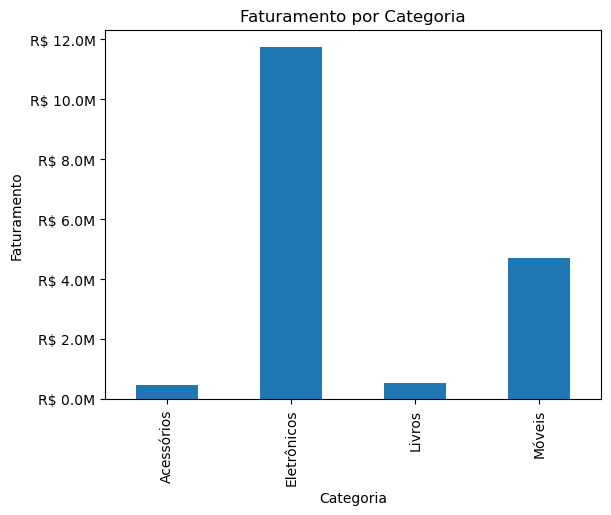

In [10]:
# 6. Criar gráfico de faturamento por categoria
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

faturamento_categoria.plot(kind='bar')
plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x/1000000:.1f}M'))

plt.show()


In [8]:
# 7. Exportar arquivo resumo_vendas.csv
resumo_vendas = vendas.groupby(['produto', 'categoria', 'cliente'])['faturamento'].sum().reset_index()
resumo_vendas.to_csv('resumo_vendas.csv', index=False)
print("Arquivo resumo_vendas.csv exportado com sucesso!")




Arquivo resumo_vendas.csv exportado com sucesso!
